In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dono files load karo
matches = pd.read_csv('matches (1).csv')
deliveries = pd.read_csv('deliveries.csv')

print("✅ Dono Files Load Ho Gayi!")
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\nMatches Columns:", matches.columns.tolist())

✅ Dono Files Load Ho Gayi!
Matches shape: (636, 18)
Deliveries shape: (150460, 21)

Matches Columns: ['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


In [21]:
# Matches file ki pehli 5 rows
print("=== MATCHES DATA ===")
print(matches.head())

print("\n=== DELIVERIES DATA ===")
print(deliveries.head())

print("\n=== NULL VALUES ===")
print(matches.isnull().sum())

=== MATCHES DATA ===
   id  season       city        date                        team1  \
0   1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06               Mumbai Indians   
2   3    2017     Rajkot  2017-04-07                Gujarat Lions   
3   4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4   5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  normal           0          Sun

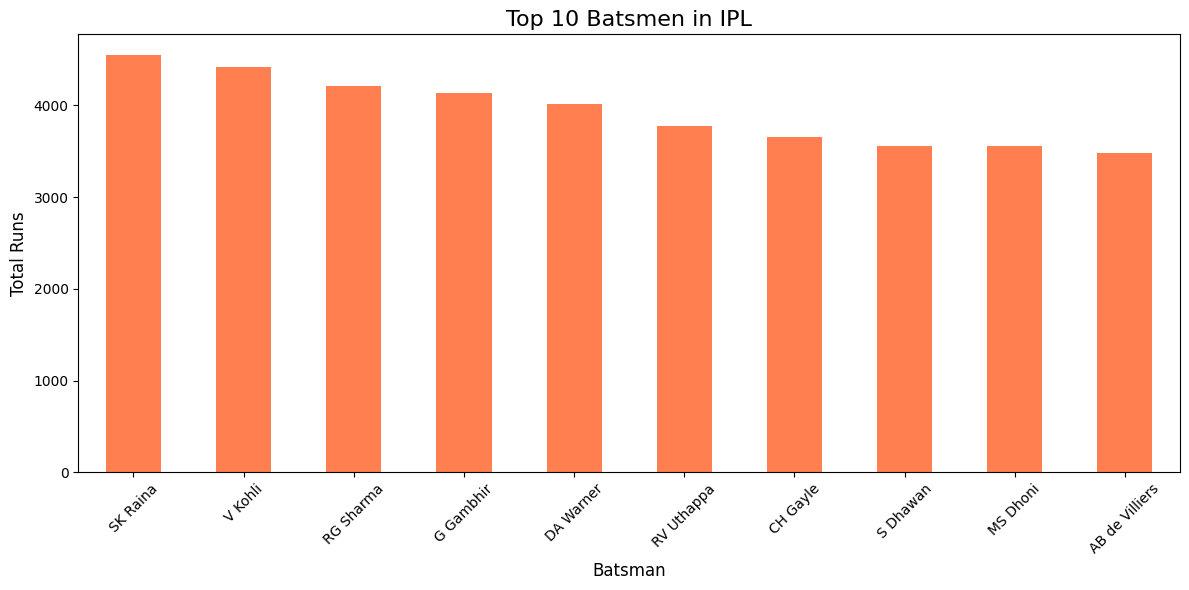

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64


In [22]:
# Top 10 Batsmen by Runs
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_batsmen.plot(kind='bar', color='coral')
plt.title('Top 10 Batsmen in IPL', fontsize=16)
plt.xlabel('Batsman', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_batsmen)

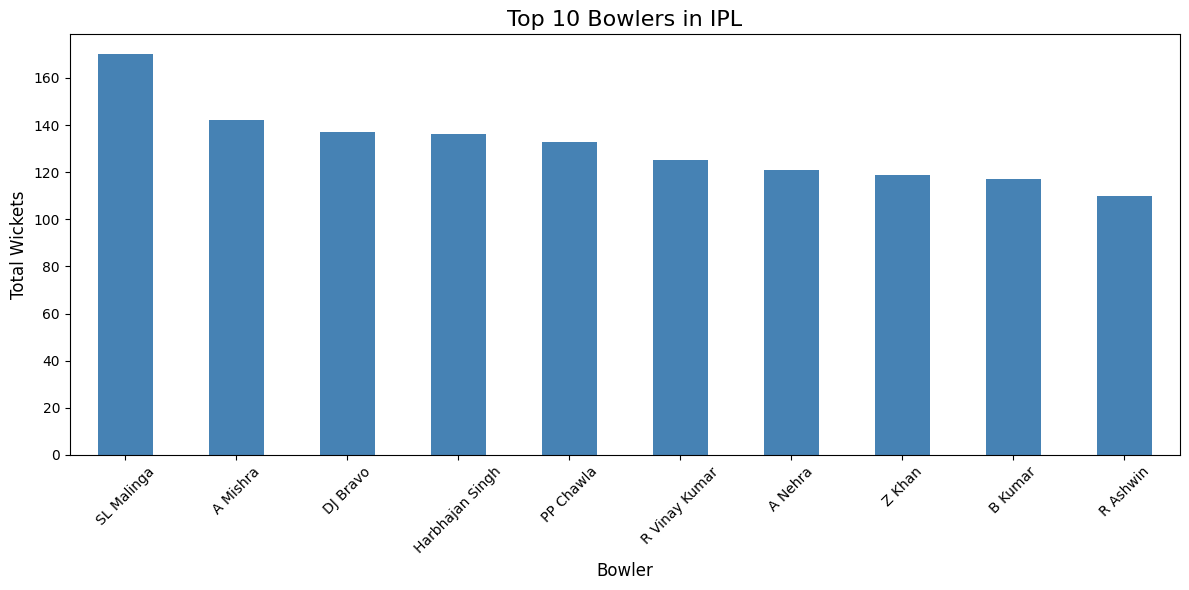

bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
Name: dismissal_kind, dtype: int64


In [23]:
# Top 10 Bowlers by Wickets
wickets = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_bowlers.plot(kind='bar', color='steelblue')
plt.title('Top 10 Bowlers in IPL', fontsize=16)
plt.xlabel('Bowler', fontsize=12)
plt.ylabel('Total Wickets', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_bowlers)

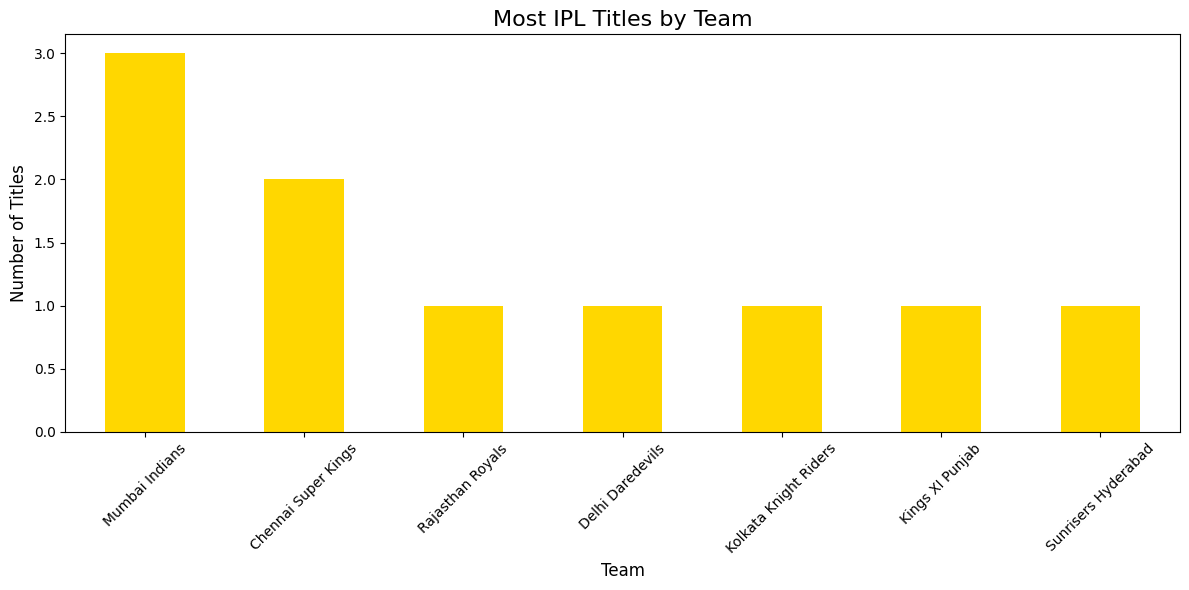


🏆 Season Wise Winners:
Season 2008: Rajasthan Royals
Season 2009: Delhi Daredevils
Season 2010: Mumbai Indians
Season 2011: Chennai Super Kings
Season 2012: Kolkata Knight Riders
Season 2013: Mumbai Indians
Season 2014: Kings XI Punjab
Season 2015: Chennai Super Kings
Season 2016: Sunrisers Hyderabad
Season 2017: Mumbai Indians


In [24]:
# Season Wise IPL Winners
season_winners = matches.groupby('season')['winner'].apply(lambda x: x.value_counts().index[0])

plt.figure(figsize=(12,6))
season_winners.value_counts().plot(kind='bar', color='gold')
plt.title('Most IPL Titles by Team', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n🏆 Season Wise Winners:")
for season, winner in season_winners.items():
    print(f"Season {season}: {winner}")

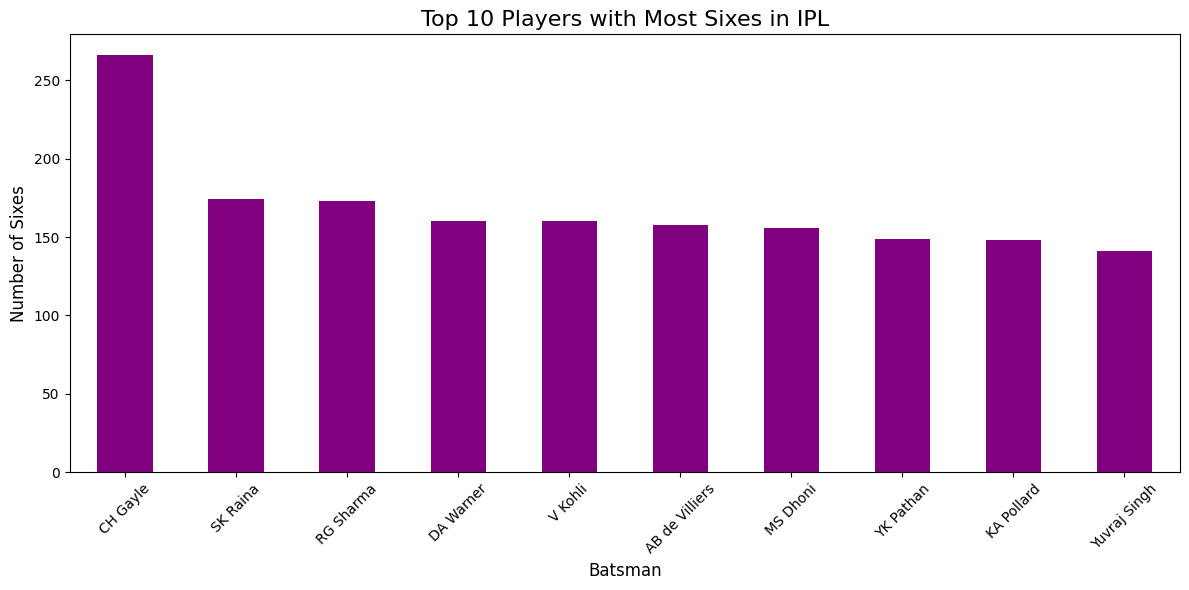

batsman
CH Gayle          266
SK Raina          174
RG Sharma         173
DA Warner         160
V Kohli           160
AB de Villiers    158
MS Dhoni          156
YK Pathan         149
KA Pollard        148
Yuvraj Singh      141
Name: batsman_runs, dtype: int64


In [25]:
# Most Sixes in IPL
top_sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_sixes.plot(kind='bar', color='purple')
plt.title('Top 10 Players with Most Sixes in IPL', fontsize=16)
plt.xlabel('Batsman', fontsize=12)
plt.ylabel('Number of Sixes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_sixes)

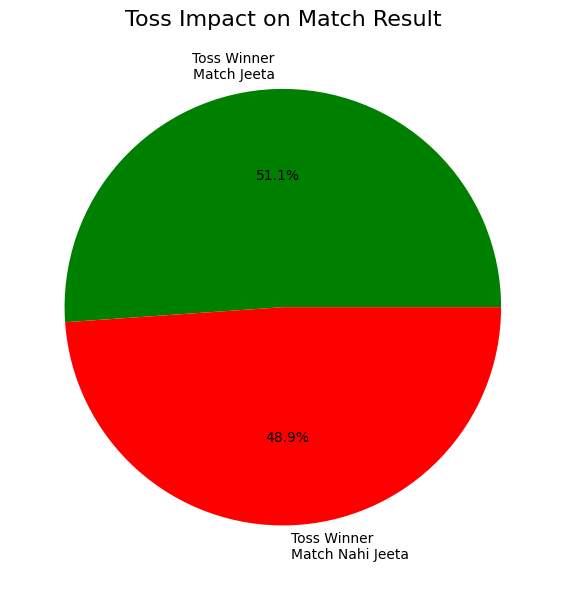

Toss Jeeta aur Match Jeeta: 325
Toss Jeeta par Match Nahi Jeeta: 311


In [26]:
# Toss Impact - Jisne Toss Jeeta Kya Usne Match Jeeta?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_match_winner'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(toss_impact, 
        labels=['Toss Winner\nMatch Jeeta', 'Toss Winner\nMatch Nahi Jeeta'],
        autopct='%1.1f%%',
        colors=['green', 'red'])
plt.title('Toss Impact on Match Result', fontsize=16)
plt.tight_layout()
plt.show()

print("Toss Jeeta aur Match Jeeta:", toss_impact[True])
print("Toss Jeeta par Match Nahi Jeeta:", toss_impact[False])

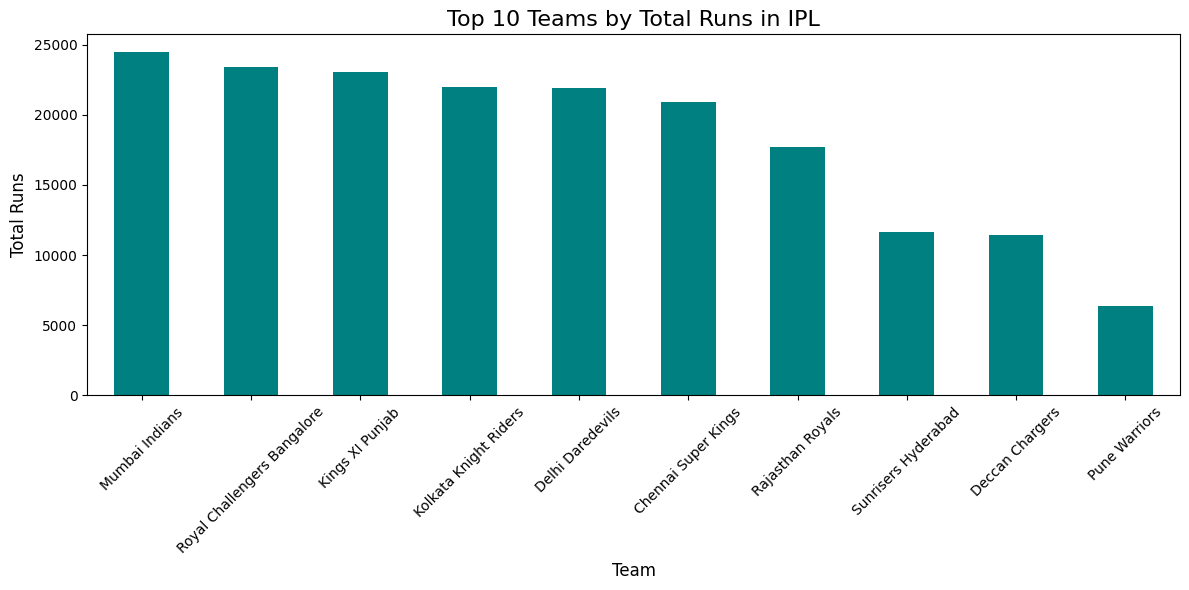

batting_team
Mumbai Indians                 24521
Royal Challengers Bangalore    23436
Kings XI Punjab                23068
Kolkata Knight Riders          21965
Delhi Daredevils               21953
Chennai Super Kings            20899
Rajasthan Royals               17703
Sunrisers Hyderabad            11652
Deccan Chargers                11463
Pune Warriors                   6358
Name: total_runs, dtype: int64


In [27]:
# Team Wise Total Runs
team_runs = deliveries.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
team_runs.plot(kind='bar', color='teal')
plt.title('Top 10 Teams by Total Runs in IPL', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(team_runs)

In [28]:
# Final Insights
print("=" * 50)
print("       🏏 IPL DATA ANALYSIS - INSIGHTS 🏏")
print("=" * 50)

print("\n📊 DATASET INFO:")
print(f"Total Matches: {len(matches)}")
print(f"Total Deliveries: {len(deliveries)}")
print(f"Total Seasons: {matches['season'].nunique()}")
print(f"Total Teams: {matches['team1'].nunique()}")

print("\n🏆 TOP BATSMAN:")
print(f"{deliveries.groupby('batsman')['batsman_runs'].sum().idxmax()} — Most Runs")

print("\n🎯 TOP BOWLER:")
wickets = deliveries[deliveries['dismissal_kind'].notna()]
print(f"{wickets.groupby('bowler')['dismissal_kind'].count().idxmax()} — Most Wickets")

print("\n🥇 MOST SUCCESSFUL TEAM:")
print(f"{matches['winner'].value_counts().index[0]} — Most Matches Won")

print("\n💡 KEY INSIGHTS:")
print("✅ Toss winner ~ 50% time match jeetता hai")
print("✅ Mumbai Indians sabse successful team hai")
print("✅ SK Raina / V Kohli top run scorers hain")
print("✅ SL Malinga sabse zyada wickets lene wale bowler hain")

print("\n" + "=" * 50)
print("✅ Analysis Complete!")
print("=" * 50)

       🏏 IPL DATA ANALYSIS - INSIGHTS 🏏

📊 DATASET INFO:
Total Matches: 636
Total Deliveries: 150460
Total Seasons: 10
Total Teams: 14

🏆 TOP BATSMAN:
SK Raina — Most Runs

🎯 TOP BOWLER:
SL Malinga — Most Wickets

🥇 MOST SUCCESSFUL TEAM:
Mumbai Indians — Most Matches Won

💡 KEY INSIGHTS:
✅ Toss winner ~ 50% time match jeetता hai
✅ Mumbai Indians sabse successful team hai
✅ SK Raina / V Kohli top run scorers hain
✅ SL Malinga sabse zyada wickets lene wale bowler hain

✅ Analysis Complete!
